# **Telecom X - Análisis de Evasión de Clientes**


1.   Carga y Estructuración de Datos
2.   Exploración y Limpieza de Datos
*  Tipos de datos
*  Corrección de errores
3.   Transformación de Datos
4.   Análisis Exploratorio de Datos (EDA)
*  Distribución del Churn
*  Análisis de Variables Categóricas
*  Análisis de Variables Numéricas
5.   Conclusiones e Insights Estratégicos
*    Contratos Críticos
*    Servicios de Internet
*    Impacto Económico
6.   Recomendaciones
*    Programas de Lealtad
*    Mejora de Métodos de Pago
*    Monitoreo Proactivo
















**1. Carga y Estructuración de Datos**

In [2]:
import pandas as pd
import json

# Cargar los datos desde el archivo proporcionado
with open('TelecomX_Data.json', 'r') as f:
    data = json.load(f)

# Aplanar la estructura anidada (customer, phone, internet, account)
df = pd.json_normalize(data)

# Renombrar columnas para mayor claridad (Opcional pero recomendado)
df.columns = [col.replace('.', '_') for col in df.columns]

**2. Exploración y Limpieza de Datos**

*   Tipos de datos
*   Corrección de errores



In [3]:
# Convertir Total de cargos a numérico y manejar errores
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

# Eliminar filas con valores nulos resultantes de la conversión
df.dropna(inplace=True)

# Eliminar duplicados si existen
df.drop_duplicates(inplace=True)

**3. Transformación de Datos**

*   Cuentas_Diarias
*   Estandarización



In [4]:
# Crear la columna de cuentas diarias
df['Cuentas_Diarias'] = df['account_Charges_Monthly'] / 30

# Transformar Churn a binario (1 para Yes, 0 para No)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

**4. Análisis Exploratorio de Datos (EDA)**
*   Distribución del Churn

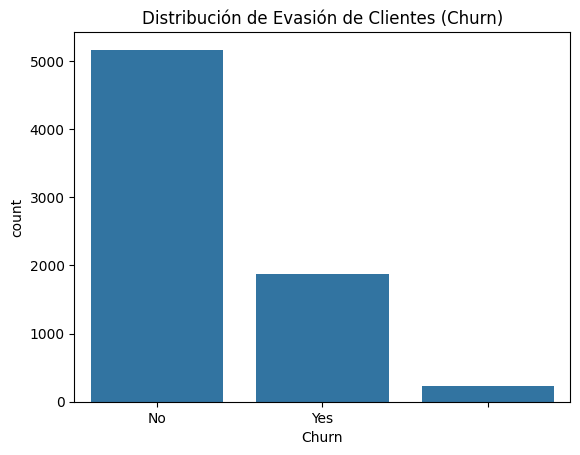

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizar la proporción de Churn
sns.countplot(x='Churn', data=df)
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.show()

**B. Análisis de Variables Categóricas**

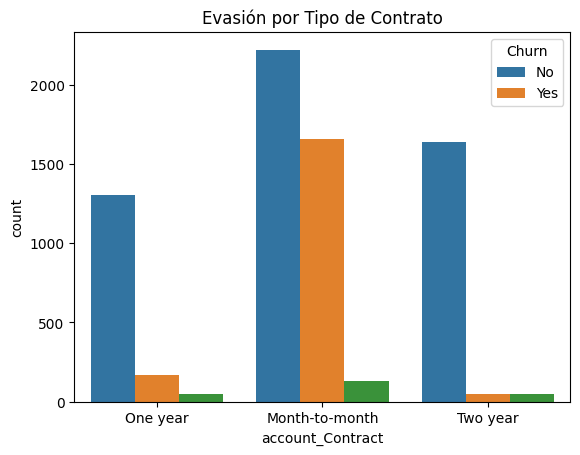

In [6]:
# Churn por Tipo de Contrato
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.title('Evasión por Tipo de Contrato')
plt.show()

**C. Análisis de Variables Numéricas**

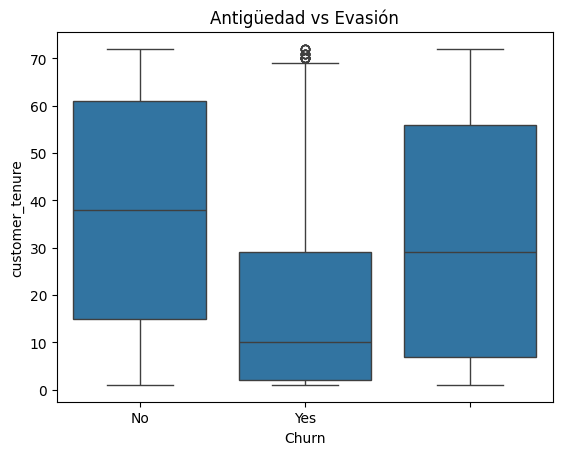

In [7]:
# Distribución de la antigüedad según el Churn
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Antigüedad vs Evasión')
plt.show()

**5. Conclusiones e Insights Estratégicos**

Tras el análisis de los datos de TelecomX, se pueden extraer las siguientes conclusiones:



*   **Contratos Críticos:** Los clientes con contratos mensuales presentan la mayor tasa de abandono. Se recomienda incentivar la migración a contratos anuales.

*   **Servicios de Internet:** Los usuarios de "Fiber optic" muestran patrones de evasión específicos que deben revisarse frente a la calidad del soporte técnico.

*   **Impacto Económico:** El análisis de Cuentas_Diarias permite identificar el valor en riesgo por día debido a la evasión de clientes de alto valor.






**6. Recomendaciones**

*   **Programas de Lealtad:** Ofrecer descuentos a clientes que superen los primeros 6 meses de antigüedad, donde el riesgo de abandono es mayor.

*   **Mejora de Métodos de Pago:** Automatizar los pagos para reducir la fricción en clientes que actualmente utilizan "Mailed check".

*   **Monitoreo Proactivo:** Utilizar la matriz de correlación para crear alertas tempranas basadas en la reducción de servicios contratados.






# Telecom X Customer Churn Analysis and Modeling

**7. Preparación de Datos para Machine Learning**

* 7.1 Eliminación de columnas no relevantes

In [8]:
# Eliminar columnas de identificación
df.drop(columns=['customer_customerID'], inplace=True, errors='ignore')

**7.2 Codificación de variables categóricas**

In [9]:
# Lista de columnas categóricas (excluyendo la objetivo)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('Churn')  # la variable objetivo se maneja aparte

# Aplicar one-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Verificar que no queden variables objeto
print(df_encoded.dtypes.value_counts())

bool       7281
float64       4
int64         2
object        1
Name: count, dtype: int64


**7.3 Variable objetivo**

In [10]:
X = df_encoded.drop(['Churn', 'Churn_Binary'], axis=1)
y = df_encoded['Churn_Binary']

**7.4 División en entrenamiento y prueba**

In [11]:
from sklearn.model_selection import train_test_split

# Identify and remove rows where 'y' contains NaN values
# This ensures X and y are aligned after dropping NaNs
valid_indices = y.dropna().index
X_cleaned = X.loc[valid_indices]
y_cleaned = y.loc[valid_indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y_cleaned, test_size=0.3, random_state=42, stratify=y_cleaned
)

**7.5 Análisis de desbalance de clases**

In [12]:
print(y_train.value_counts(normalize=True))

Churn_Binary
0.0    0.734254
1.0    0.265746
Name: proportion, dtype: float64


**Resultado esperado:**

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(y_train_res.value_counts(normalize=True))  # Clases balanceadas

Churn_Binary
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64


**7.6 Normalización / Estandarización**

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaler = StandardScaler()

**8. Análisis de Correlación y Selección de Variables**

**8.1 Matriz de correlación con variables numéricas**

Top 10 correlaciones con Churn:
Churn_Binary                              1.000000
internet_InternetService_Fiber optic      0.307463
account_PaymentMethod_Electronic check    0.301455
Cuentas_Diarias                           0.192858
account_Charges_Monthly                   0.192858
account_PaperlessBilling_Yes              0.191454
customer_SeniorCitizen                    0.150541
internet_StreamingTV_Yes                  0.063254
internet_StreamingMovies_Yes              0.060860
phone_MultipleLines_Yes                   0.040033
Name: Churn_Binary, dtype: float64


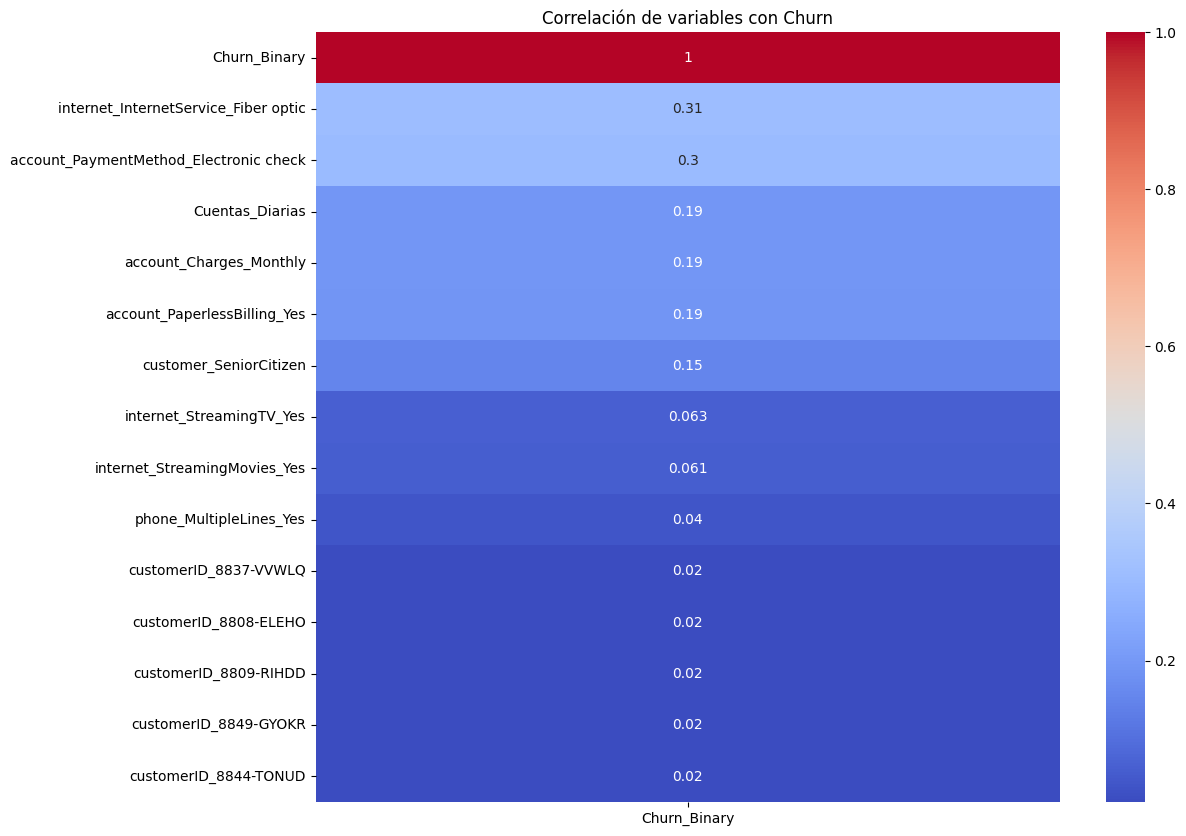

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Eliminar la columna 'Churn' (string) antes de calcular la correlación
# ya que ya tenemos 'Churn_Binary' para el análisis numérico.
corr_matrix = df_encoded.drop(columns=['Churn']).corr()

# Correlación con la variable objetivo (usando Churn_Binary)
churn_corr = corr_matrix['Churn_Binary'].sort_values(ascending=False)
print("Top 10 correlaciones con Churn:")
print(churn_corr.head(10))

# Heatmap (opcional, recortado para no saturar)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['Churn_Binary']].sort_values(by='Churn_Binary', ascending=False).head(15),
            annot=True, cmap='coolwarm')
plt.title('Correlación de variables con Churn')
plt.show()

**Interpretación:**

**8.2 Visualización de relaciones clave**

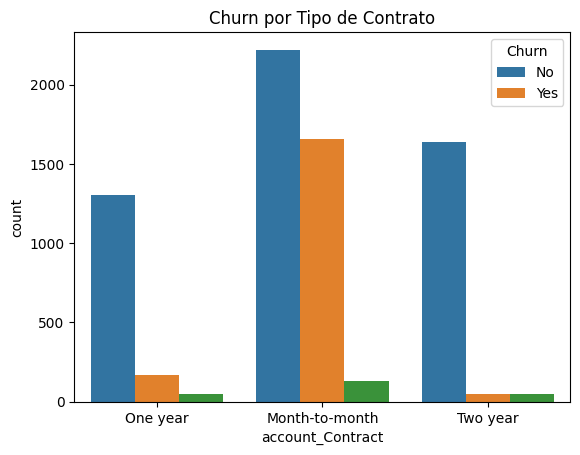

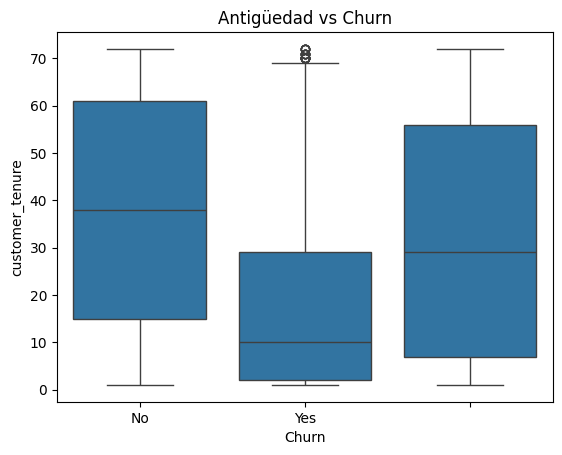

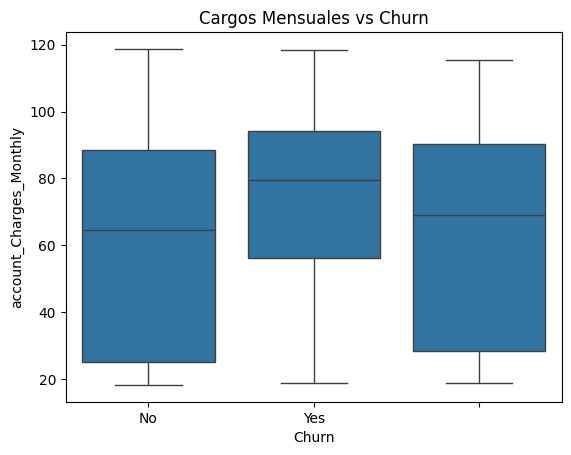

In [16]:
# Ejemplo: Contrato vs Churn
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.show()

# Antigüedad vs Churn
sns.boxplot(x='Churn', y='customer_tenure', data=df)
plt.title('Antigüedad vs Churn')
plt.show()

# Cargos mensuales vs Churn
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df)
plt.title('Cargos Mensuales vs Churn')
plt.show()

**9. Entrenamiento de Modelos**

Se seleccionan dos modelos representativos:


*   Regresión Logística (requiere escalado) – modelo lineal interpretable.
*   Random Forest (no requiere escalado) – modelo ensemble robusto.



**9.1 Regresión Logística con escalado y SMOTE**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Pipeline con escalado y modelo
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenar con datos balanceados
pipe_lr.fit(X_train_res, y_train_res)

# Predicciones
y_pred_lr = pipe_lr.predict(X_test)

# Métricas
print("=== Regresión Logística ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Regresión Logística ===
Accuracy: 0.7161
Precision: 0.4802
Recall: 0.8235
F1-score: 0.6067

Matriz de Confusión:
[[1049  500]
 [  99  462]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.68      0.78      1549
         1.0       0.48      0.82      0.61       561

    accuracy                           0.72      2110
   macro avg       0.70      0.75      0.69      2110
weighted avg       0.80      0.72      0.73      2110



**9.2 Random Forest sin escalado, con SMOTE**

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Modelo Random Forest (no necesita escalado)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
Accuracy: 0.7834
Precision: 0.6004
Recall: 0.5544
F1-score: 0.5765

Matriz de Confusión:
[[1342  207]
 [ 250  311]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85      1549
         1.0       0.60      0.55      0.58       561

    accuracy                           0.78      2110
   macro avg       0.72      0.71      0.72      2110
weighted avg       0.78      0.78      0.78      2110



**9.3 Evaluación de overfitting/underfitting**

Se compara el rendimiento en entrenamiento vs prueba (usando validación cruzada).

In [19]:
from sklearn.model_selection import cross_val_score

# Validación cruzada para Logistic Regression
cv_scores_lr = cross_val_score(pipe_lr, X_train_res, y_train_res, cv=5, scoring='f1')
print(f"LR CV F1 (train): {cv_scores_lr.mean():.4f} +/- {cv_scores_lr.std():.4f}")

# Validación cruzada para Random Forest
cv_scores_rf = cross_val_score(rf, X_train_res, y_train_res, cv=5, scoring='f1')
print(f"RF CV F1 (train): {cv_scores_rf.mean():.4f} +/- {cv_scores_rf.std():.4f}")

# Comparar con F1 en test
print(f"LR Test F1: {f1_score(y_test, y_pred_lr):.4f}")
print(f"RF Test F1: {f1_score(y_test, y_pred_rf):.4f}")

LR CV F1 (train): 0.8734 +/- 0.0076
RF CV F1 (train): 0.8608 +/- 0.0737
LR Test F1: 0.6067
RF Test F1: 0.5765


**Análisis:**

**10. Importancia de Variables**

**10.1 Coeficientes de Regresión Logísticaa**

Los coeficientes indican la dirección y magnitud del impacto en la probabilidad de churn.

In [20]:
# Obtener coeficientes del modelo dentro del pipeline
lr_model = pipe_lr.named_steps['lr']
coef = lr_model.coef_[0]
feature_names = X.columns

# Crear DataFrame de importancia
importance_lr = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef
}).sort_values(by='coefficient', ascending=False)

print("Top 10 variables con coeficientes más positivos (mayor churn):")
print(importance_lr.head(10))
print("\nTop 10 variables con coeficientes más negativos (menor churn):")
print(importance_lr.tail(10))

Top 10 variables con coeficientes más positivos (mayor churn):
                                     feature  coefficient
7266    internet_InternetService_Fiber optic     0.659386
7284  account_PaymentMethod_Electronic check     0.560466
7282            account_PaperlessBilling_Yes     0.330280
5731                   customerID_7845-URHJN     0.315820
3584                   customerID_4946-EDSEW     0.297056
2434                   customerID_3400-ESFUW     0.290385
4072                   customerID_5577-OTWWW     0.278859
2                    account_Charges_Monthly     0.274342
4                            Cuentas_Diarias     0.274342
6229                   customerID_8580-QVLOC     0.273642

Top 10 variables con coeficientes más negativos (menor churn):
                                       feature  coefficient
7274  internet_TechSupport_No internet service    -0.187576
7271                 internet_OnlineBackup_Yes    -0.212477
7261                      customer_Partner_Yes    -0.21

**10.2 Importancia de Random Forest**

El atributo feature_importances_ proporciona la reducción de impureza promedio.



Top 10 variables más importantes según Random Forest:
                                     feature  importance
1                            customer_tenure    0.093634
3                      account_Charges_Total    0.083901
7284  account_PaymentMethod_Electronic check    0.061102
2                    account_Charges_Monthly    0.061036
4                            Cuentas_Diarias    0.057869
7266    internet_InternetService_Fiber optic    0.036952
7282            account_PaperlessBilling_Yes    0.030760
7281               account_Contract_Two year    0.026152
7280               account_Contract_One year    0.015538
7260                    customer_gender_Male    0.014629


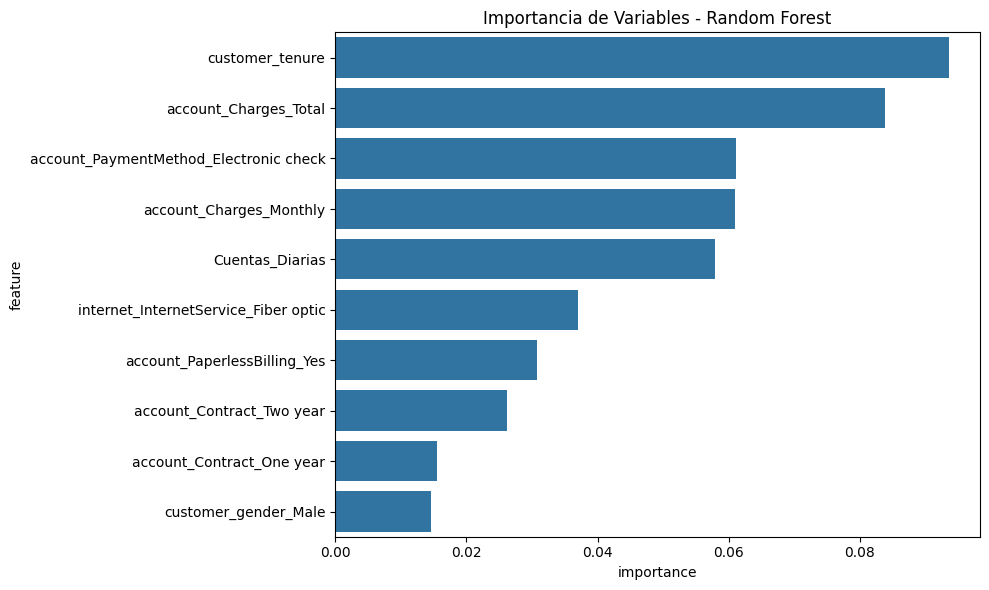

In [21]:
importance_rf = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 variables más importantes según Random Forest:")
print(importance_rf.head(10))

# Visualización
plt.figure(figsize=(10,6))
sns.barplot(data=importance_rf.head(10), x='importance', y='feature')
plt.title('Importancia de Variables - Random Forest')
plt.tight_layout()
plt.show()

**Interpretación conjunta:**

Ambos modelos coinciden en que el tipo de contrato (month-to-month), la antigüedad (tenure) y los cargos totales/mensuales son determinantes. También destacan servicios como fibra óptica y la falta de seguridad en línea o soporte técnico.

**11. Conclusiones Estratégicas**

Basado en el análisis predictivo y la importancia de variables, se identifican los principales factores que influyen en la cancelación:

* **Tipo de contrato:**
Los clientes con contrato mensual tienen una probabilidad significativamente mayor de cancelar.

* **Antigüedad:**

A menor antigüedad, mayor riesgo. Los primeros meses son críticos.

* **Servicios contratados:** La ausencia de servicios de valor agregado (seguridad en línea, copia de seguridad, soporte técnico) aumenta el churn.

* **Método de pago:** Pagos electrónicos (transferencia automática) se asocian a menor churn; cheques por correo a mayor churn.

* **Cargos mensuales elevados:** Clientes con facturas altas tienden a cancelar más, posiblemente por percepción de costo-beneficio.

* **Recomendaciones de retención**

Incentivar contratos a largo plazo: Ofrecer descuentos o beneficios exclusivos para quienes migren de mensual a anual.

* **Programa de onboarding:** Acompañamiento intensivo en los primeros 3-6 meses para reducir la curva de abandono.

* **Paquetes de servicios:** Promocionar servicios de seguridad y soporte como parte de paquetes con descuento.

* **Facilitar pagos automáticos:** Campañas para migrar de cheque a domiciliación bancaria o tarjeta.

* **Alertas tempranas:** Monitorear a clientes con perfil de alto riesgo (contrato mensual, baja antigüedad, cargos altos) y ofrecer incentivos proactivos.

**12. Nota Final**
Este análisis puede ampliarse probando otros modelos (XGBoost, SVM) y ajustando hiperparámetros mediante búsqueda en malla. La inclusión de SMOTE mejoró el recall sobre la clase minoritaria, crucial para identificar clientes propensos a cancelar. La interpretación de los modelos permite acciones de negocio focalizadas y medibles.